# Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Step 2: Load Stock Data

In [4]:
stock_symbol = "AAPL"
df = yf.download(stock_symbol, start="2020-01-01", end="2024-12-31")


[*********************100%***********************]  1 of 1 completed


In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468262,72.528582,71.223259,71.476600,135480400
2020-01-03,71.763718,72.523746,71.539330,71.696160,146322800
2020-01-06,72.335556,72.374162,70.634539,70.885472,118387200
2020-01-07,71.995361,72.600968,71.775796,72.345212,108872000
2020-01-08,73.153503,73.455103,71.698589,71.698589,132079200


# Step 3: Data Understanding

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1257 non-null   float64
 1   (High, AAPL)    1257 non-null   float64
 2   (Low, AAPL)     1257 non-null   float64
 3   (Open, AAPL)    1257 non-null   float64
 4   (Volume, AAPL)  1257 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


In [8]:
df.shape

(1257, 5)

In [9]:
df.size

6285

In [10]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,151.581359,153.104914,149.880723,151.425033,9.061168e+07
std,41.855808,41.994326,41.630784,41.795290,5.324605e+07
min,54.264336,55.263186,51.420157,55.161608,2.323470e+07
25%,126.484444,127.570927,124.465612,125.957958,5.546960e+07
50%,150.220779,151.972500,148.223238,150.046364,7.629970e+07
75%,176.073013,177.774679,174.640093,175.919612,1.077601e+08
max,257.853760,258.928914,256.470034,257.027510,4.265100e+08


# Step 4: Feature Selection & Target Creation

In [12]:
df['Target_Close'] = df['Close'].shift(-1)
df.dropna(inplace=True)


In [13]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target_Close']


# Step 5: Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


# Step 6: Train Linear Regression Model

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

# Step 7: Make Predictions

In [19]:
y_pred = model.predict(X_test)


# Step 8: Model Evaluation

In [21]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)


Mean Absolute Error (MAE): 2.335022627519738
Root Mean Squared Error (RMSE): 3.103478968666438


# Step 9: Actual vs Predicted Plot

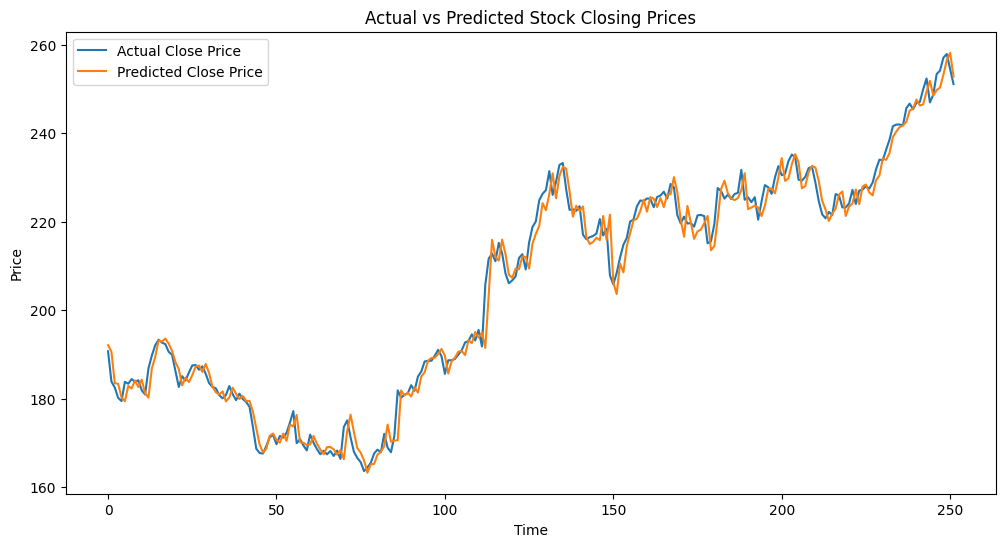

In [23]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Close Price')
plt.plot(y_pred, label='Predicted Close Price')
plt.title('Actual vs Predicted Stock Closing Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


# Step 10: Predict Next Day Price

In [25]:
last_day = df[['Open', 'High', 'Low', 'Volume']].iloc[-1:]
next_day_price = model.predict(last_day)

print("Predicted Next Day Closing Price:", next_day_price[0])


Predicted Next Day Closing Price: 252.77363480624317


# Final Insights

The model predicts the next day’s stock price based on historical trends.

Linear Regression is simple but effective for short-term predictions.

Stock prices are highly volatile → making this a good exercise for learning ML concepts.